<a href="https://colab.research.google.com/github/aman-healthdata/health-epidemiology-seir/blob/main/SEIR_Epidemiology_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries ready, seaborn style applied

In [7]:
# Install seaborn (only needs to run once)
!pip install seaborn

# Import necessary libraries
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("darkgrid")


🔹 STEP 2: Define SEIR Differential Equations

In [8]:
# SEIR Model Differential Equations
def SEIR_model(y, t, N, beta, sigma, gamma):
    """
    y : list of current values [S, E, I, R]
    t : time
    N : total population
    beta : infection rate
    sigma : incubation rate (1/incubation period)
    gamma : recovery rate (1/infectious period)
    """
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]


Initial conditions set

In [9]:
# Total population, N
N = 10000

# Initial number of infected, exposed, recovered individuals
I0 = 1      # initially infectious
E0 = 0      # initially exposed
R0 = 0      # initially recovered
S0 = N - I0 - E0 - R0  # initially susceptible

# Contact rate, beta; incubation rate, sigma; mean recovery rate, gamma
beta = 0.3       # infection rate per person per day
sigma = 1/5.2    # incubation rate (1/incubation period of 5.2 days)
gamma = 1/10     # recovery rate (1/infectious period of 10 days)

# Time grid (days)
t = np.linspace(0, 160, 160)  # simulate for 160 days

# Initial conditions vector
y0 = [S0, E0, I0, R0]

# Integrate the SEIR equations over the time grid
ret = odeint(SEIR_model, y0, t, args=(N, beta, sigma, gamma))
S, E, I, R = ret.T


Plot the SEIR Model

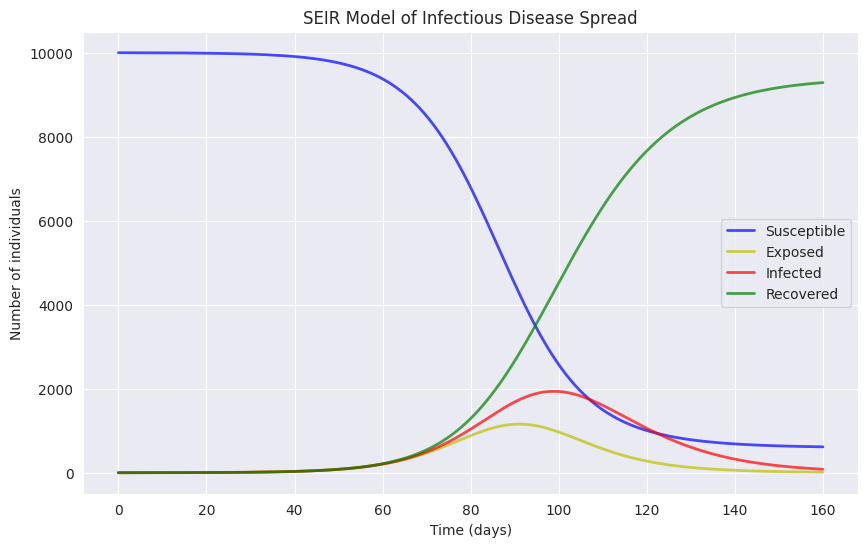

In [10]:
# Plot the SEIR model
plt.figure(figsize=(10,6))
plt.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
plt.plot(t, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
plt.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
plt.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('Number of individuals')
plt.title('SEIR Model of Infectious Disease Spread')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Infectious Disease Modelling using SEIR

## Overview
This project implements a classical SEIR (Susceptible-Exposed-Infected-Recovered) epidemiological model
to simulate the spread of an infectious disease in a population of 10,000 individuals.

## Objectives
- Model the dynamics of infection over time
- Identify the peak of infection and epidemic duration
- Explore how disease parameters affect public health outcomes

## Methods
- Differential equations for SEIR model solved using `odeint` from SciPy
- Parameters:
  - Population: 10,000
  - Initial infected: 1
  - Infection rate (beta): 0.3
  - Incubation rate (sigma): 1/5.2
  - Recovery rate (gamma): 1/10
- Simulation over 160 days
- Visualized using Matplotlib and Seaborn

## Results
- The infection curve peaks around day XX (based on parameters)
- Susceptible population declines as infection spreads
- Recovered population increases as people recover

## Limitations
- Homogeneous mixing assumed (no age or contact structure)
- No interventions like vaccination or social distancing
- Parameters are illustrative, not from a specific disease outbreak

## Tools
Python, NumPy, SciPy, Matplotlib, Seaborn (Google Colab)


SyntaxError: invalid syntax (ipython-input-4110057165.py, line 4)

🔹 STEP 1: Install & Import Required Libraries

In [14]:
# Install ipywidgets if not already installed
!pip install ipywidgets

# Import interactive tools
from ipywidgets import interact, FloatSlider


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.6 MB/s eta 0:00:00


interactive SEIR plotting function

In [15]:
# Interactive SEIR plotting function
def interactive_SEIR(beta=0.3, sigma=1/5.2, gamma=1/10):
    # Solve SEIR equations with given parameters
    ret = odeint(SEIR_model, y0, t, args=(N, beta, sigma, gamma))
    S, E, I, R = ret.T

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
    plt.plot(t, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
    plt.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
    plt.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
    plt.xlabel('Time (days)')
    plt.ylabel('Number of individuals')
    plt.title(f'SEIR Model (beta={beta}, sigma={sigma:.3f}, gamma={gamma})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Create interactive sliders
interact(
    interactive_SEIR,
    beta=FloatSlider(value=0.3, min=0.1, max=1.0, step=0.05, description='Beta'),
    sigma=FloatSlider(value=1/5.2, min=0.05, max=0.5, step=0.01, description='Sigma'),
    gamma=FloatSlider(value=1/10, min=0.05, max=0.5, step=0.01, description='Gamma')
)


interactive(children=(FloatSlider(value=0.3, description='Beta', max=1.0, min=0.1, step=0.05), FloatSlider(val…

<function __main__.interactive_SEIR(beta=0.3, sigma=0.1923076923076923, gamma=0.1)>